# Customer Churn Analysis 

Import Libraries


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [3]:
df = pd.read_csv("C:/Users/akash/OneDrive/Desktop/AKASH BHAI FILE/Projects/Customer-Churn-analysis/Excel Cleaning/Telco-Customer-Churn.csv")
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerTenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Mid-term
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Long-term
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New


Understand the dataset

In [4]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (7043, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           7043 non-null   object 
 1   Gender               7043 non-null   object 
 2   SeniorCitizen        7043 non-null   int64  
 3   Partner              7043 non-null   object 
 4   Dependents           7043 non-null   object 
 5   Tenure               7043 non-null   int64  
 6   PhoneService         7043 non-null   object 
 7   MultipleLines        7043 non-null   object 
 8   InternetService      7043 non-null   object 
 9   OnlineSecurity       7043 non-null   object 
 10  OnlineBackup         7043 non-null   object 
 11  DeviceProtection     7043 non-null   object 
 12  TechSupport          7043 non-null   object 
 13  StreamingTV          7043 non-null   object 
 14  StreamingMovies      7043 non-null   object 
 15  Contract 

In [5]:
df.isnull().sum()

CustomerID             0
Gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
Tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
CustomerTenureGroup    0
dtype: int64

Check churn Disribution


In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

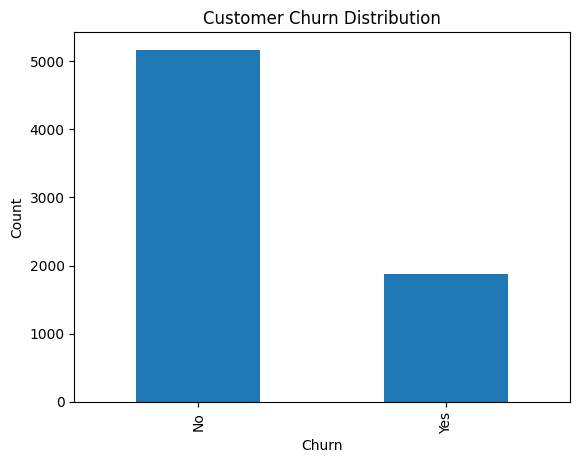

In [7]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

- Insight: Most customers did not churn, but a significant number did churn, showing a meaningful retention problem.

Compare Tenure by Churn

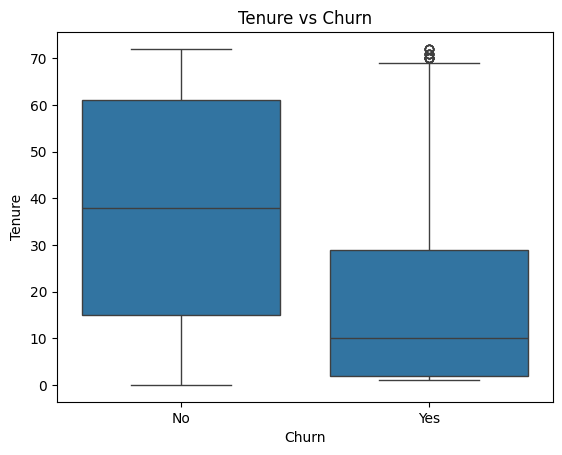

In [8]:
sns.boxplot(x="Churn", y="Tenure", data = df)
plt.title("Tenure vs Churn")
plt.show()

- Insight: Newer Customers are more likely to churn than long-term customers.

Compare monthly charges by churn

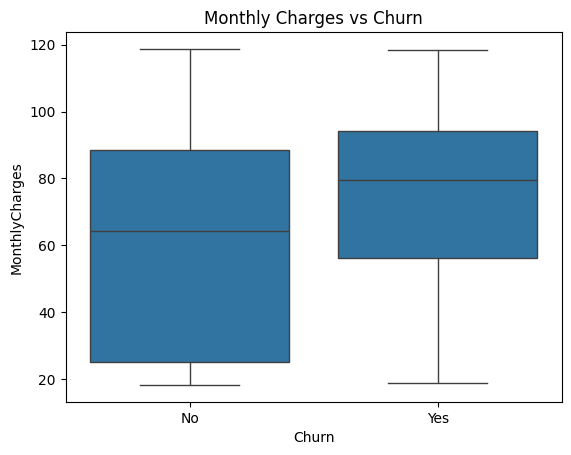

In [9]:
sns.boxplot(x="Churn", y = "MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

- Higher monthly charge appear associated with increased churn risk.

Churn by Contract type

In [10]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


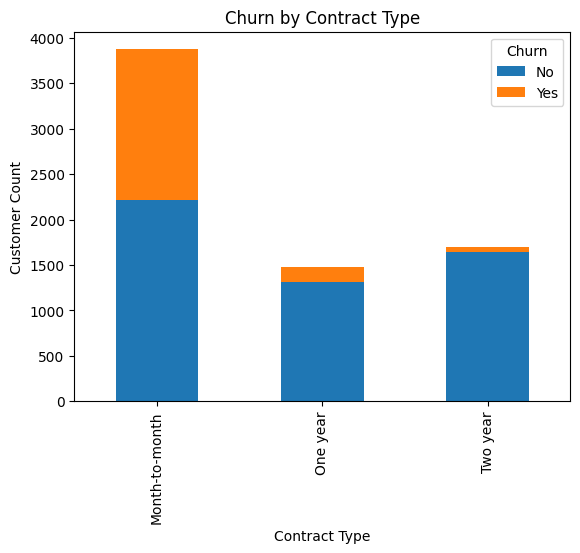

In [11]:
contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()

- Insight: Month-to-month customer churn much more than one-year or two-year or two year contract customers.

Churn by Internet Service

In [12]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])
internet_churn

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


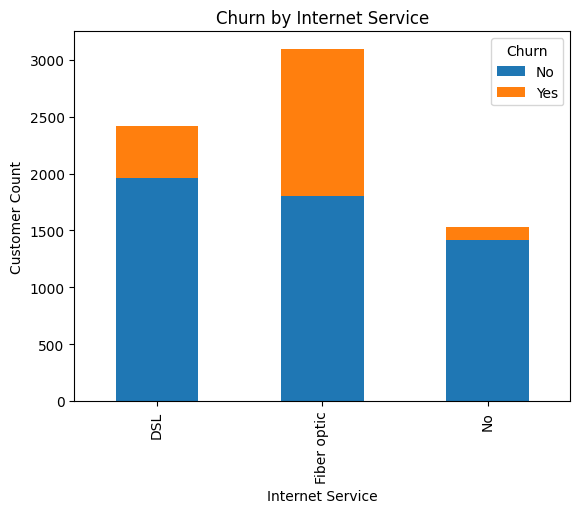

In [13]:
internet_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.show()

- Insight: Fiber optic shows higher churn rate.

Correlation for numeric columns

In [14]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.corr()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
Tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


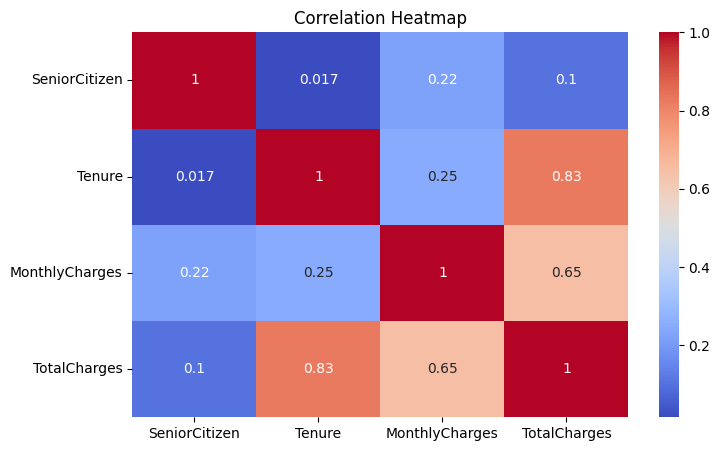

In [15]:
plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**EDA Insights**

- Customers with lower tenure churn more frequently.

- Higher monthly charges are associated with churn.

- Month-to-month contracts have the highest churn.

- Fiber optic internet users tend to churn more.

- Churn is imbalanced but still significant enough for predictive modeling.

**Model Preparation**

In [16]:
# Convert target column
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [17]:
# Removing CustomerID because it is just an identifier
df = df.drop("CustomerID", axis = 1)

In [18]:
# Convert Categorical Columns into number: encoding

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerTenureGroup_Mid-term,CustomerTenureGroup_New
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,True,False,True,False,False,True
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,True,False,False,False,False,True,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,True,False,False,True,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,True,False,True,False,False,True


In [19]:
# Seperate feature and target

X = df_encoded.drop("Churn", axis = 1)
y = df_encoded["Churn"]

In [20]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\akash\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
# Predictions
y_pred = model.predict(X_test)

In [23]:
# Evaluate the model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8133427963094393

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409


Confusion Matrix:
 [[934 102]
 [161 212]]


In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values("Abs_Coefficient", ascending=False)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
25,Contract_Two year,-0.719967,0.719967
13,OnlineSecurity_Yes,-0.596559,0.596559
10,InternetService_Fiber optic,0.559865,0.559865
19,TechSupport_Yes,-0.542325,0.542325
30,CustomerTenureGroup_Mid-term,-0.506978,0.506978
7,PhoneService_Yes,-0.460865,0.460865
26,PaperlessBilling_Yes,0.410894,0.410894
24,Contract_One year,-0.382490,0.382490
8,MultipleLines_No phone service,0.274586,0.274586
23,StreamingMovies_Yes,0.266334,0.266334


- Insights: Customers with two-year contracts are much less likely to churn.
- Customers who have online security and tech support services churn less.
- Customers using fiber optic internet are more likely to churn.
- Customers using paperless billing churn more frequently.
- Customers with longer tenure are less likely to churn.

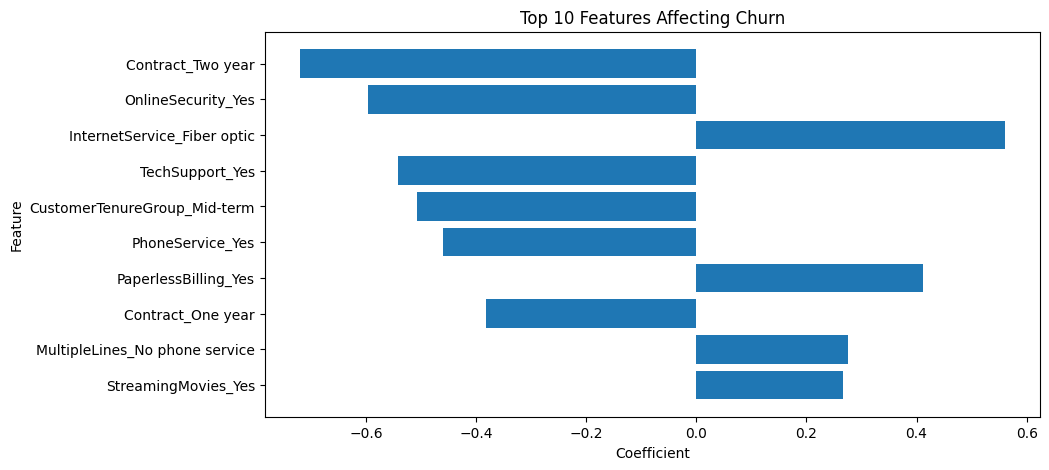

In [25]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top 10 Features Affecting Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

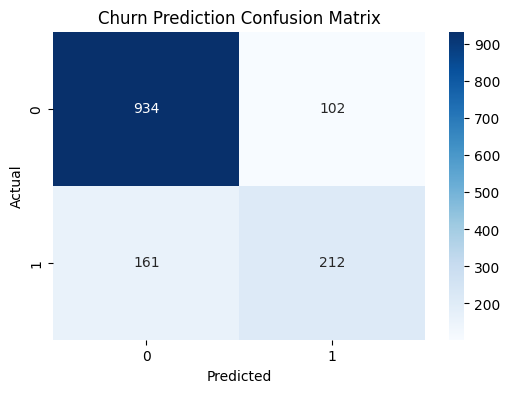

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Churn Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- Summary of the Model: Customer with short contracts, higher monthly charges, and fiber optic service show higher churn risk. Long-term contracts, security services, and longer tenure significantly reduce churn probability.